In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install torchvision

In [ ]:
import torchvision
from torchvision import datasets
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms

print(f"Pytorch version: {torch.__version__}\ntorchvision version:{torchvision.__version__}")


Pytorch version: 2.11.0+cpu
torchvision version:0.26.0+cpu


In [ ]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=transforms.ToTensor(),
    download=True,
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


In [ ]:
image, label = train_data[0]
print(f"image dim: {image.ndim}")
print(f"label: {label}")

image dim: 3
label: 9


In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
# colour, height and width

In [ ]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [ ]:
class_names = train_data.classes

In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

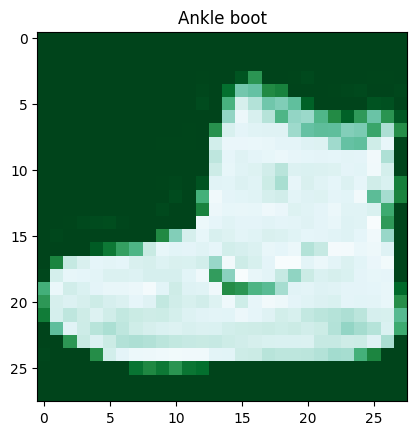

In [ ]:
plt.imshow(image.squeeze(),cmap='BuGn_r')
plt.title(class_names[label])
plt.show()

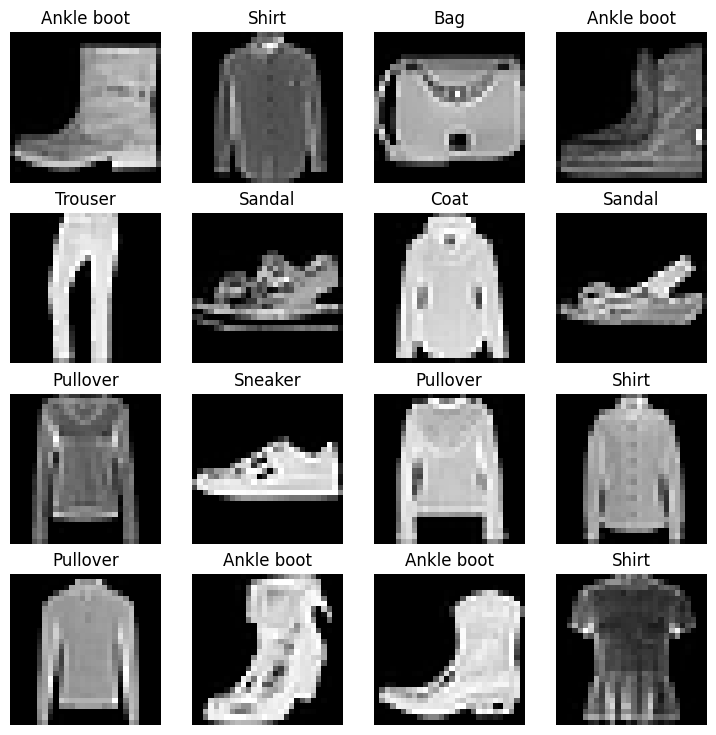

In [ ]:
torch.manual_seed(42)

figure = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1,rows*cols+1):
  random_idx = torch.randint(0,len(train_data),size=[1]).item()
  image, label = train_data[random_idx]
  figure.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_names[label])


In [ ]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

print(f"DataLoaders: {train_dataloader,test_dataloader}")
print(f"length of train_dataloader: {len(train_dataloader)} batches of : {BATCH_SIZE}")
print(f"length of test_dataloader: {len(test_dataloader)} batches of : {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7d6a9053bfe0>, <torch.utils.data.dataloader.DataLoader object at 0x7d6a9425f950>)
length of train_dataloader: 1875 batches of : 32
length of test_dataloader: 313 batches of : 32


In [ ]:
train_features_batch, train_features_label = next(iter(train_dataloader))
test_features_batch, test_features_label = next(iter(test_dataloader))
print(train_features_batch.shape, train_features_label.shape)

torch.Size([32, 1, 28, 28]) torch.Size([32])


In [ ]:
flatten_model = nn.Flatten()

x = train_features_batch[0]

output = flatten_model(x)

print(f"Shape before flattening: {x.shape} -> [colour_channels,height,width]")
print(f"Shape after flattening: {output.shape} -> [colour_channels,height*width]")

print(x)
print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [colour_channels,height,width]
Shape after flattening: torch.Size([1, 784]) -> [colour_channels,height*width]
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0

In [ ]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape))

  def forward(self,x):
    return self.layer_stack(x)


model_0 = FashionMNISTModelV0(input_shape = 784,output_shape=len(class_names),hidden_units = 10)
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0330, -0.0238,  0.0294,  ...,  0.0195, -0.0210,  0.0300],
                      [-0.0145,  0.0286,  0.0324,  ...,  0.0297,  0.0300,  0.0059],
                      [-0.0343, -0.0305,  0.0264,  ..., -0.0035, -0.0163, -0.0080],
                      ...,
                      [ 0.0190, -0.0183, -0.0244,  ...,  0.0003,  0.0092, -0.0110],
                      [ 0.0201,  0.0348, -0.0352,  ...,  0.0076, -0.0161, -0.0216],
                      [-0.0254,  0.0320, -0.0231,  ...,  0.0104,  0.0163,  0.0282]])),
             ('layer_stack.1.bias',
              tensor([-0.0243, -0.0329, -0.0140,  0.0030, -0.0282, -0.0088, -0.0261, -0.0270,
                       0.0108,  0.0174])),
             ('layer_stack.2.weight',
              tensor([[ 0.0426,  0.2194, -0.0758,  0.0409,  0.2332,  0.2619,  0.0905, -0.2700,
                        0.0765,  0.2279],
                      [ 0.1077, -0.3115, -0.1033, -0.1620, -0.2846, -0.2631,  0.

In [ ]:
model_0.to('cpu')

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  # Note: you need the "raw" GitHub URL for this to work
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(),
                             lr=0.1)

ModuleNotFoundError: No module named 'helper_functions'

In [ ]:
import torch
from torch.utils.data import Dataset


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from torch import nn

In [ ]:
import zipfile
from pathlib import Path
import requests

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


In [ ]:
import os
def walk_through_dir(dir_path):
  for root, dirs, files in os.walk(dir_path):
    print(f"there are {len(dirs)} directories and {len(files)} images in inside {root} directory")

In [ ]:
train_dir = image_path / "train"
walk_through_dir(str(train_dir))

there are 3 directories and 0 images in inside data/pizza_steak_sushi/train directory
there are 0 directories and 72 images in inside data/pizza_steak_sushi/train/sushi directory
there are 0 directories and 78 images in inside data/pizza_steak_sushi/train/pizza directory
there are 0 directories and 75 images in inside data/pizza_steak_sushi/train/steak directory


In [ ]:
test_dir = image_path / "test"
walk_through_dir(str(test_dir))

there are 3 directories and 0 images in inside data/pizza_steak_sushi/test directory
there are 0 directories and 31 images in inside data/pizza_steak_sushi/test/sushi directory
there are 0 directories and 25 images in inside data/pizza_steak_sushi/test/pizza directory
there are 0 directories and 19 images in inside data/pizza_steak_sushi/test/steak directory


image_class: sushi
Image path: data/pizza_steak_sushi/train/sushi/855721.jpg
image height:512
image width:384


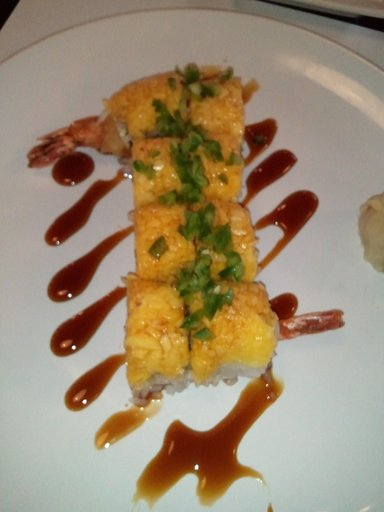

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

all_image_paths = list(image_path.glob('*/*/*.jpg'))

random_image_path = random.choice(all_image_paths)
random_image_class = random_image_path.parent.stem

image = Image.open(random_image_path)
print(f"image_class: {random_image_class}")
print(f"Image path: {random_image_path}")
print(f"image height:{image.height}")
print(f"image width:{image.width}")

image

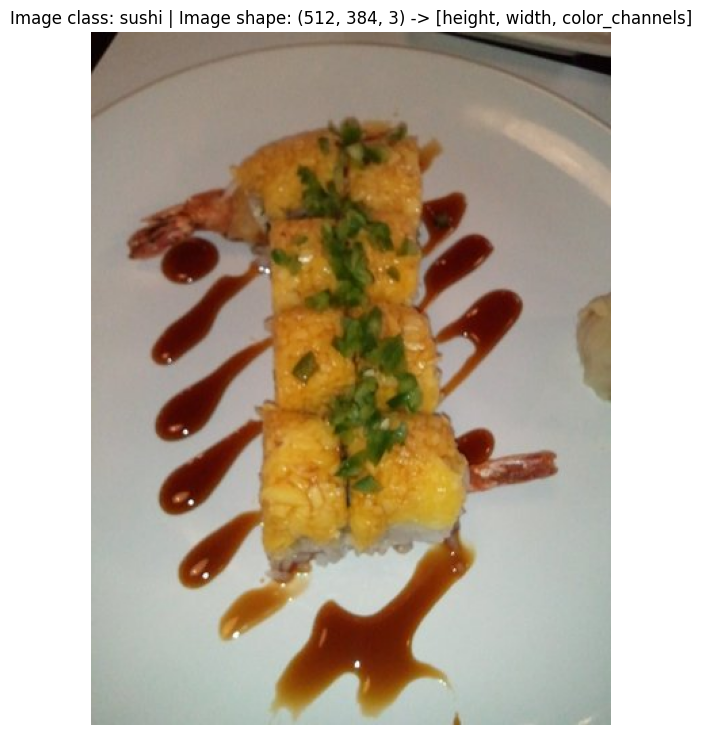

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img_as_array = np.asarray(image)
plt.figure(figsize=(10,9))
plt.imshow(img_as_array)
plt.title(f"Image class: {random_image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform_data = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor()]
)

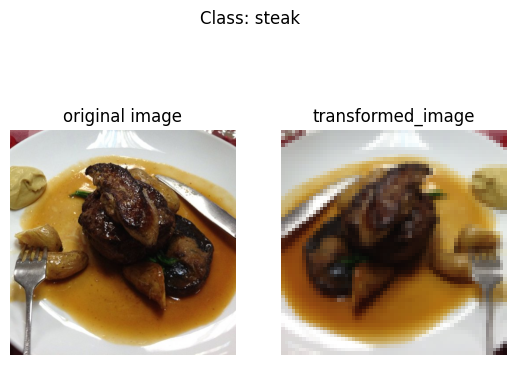

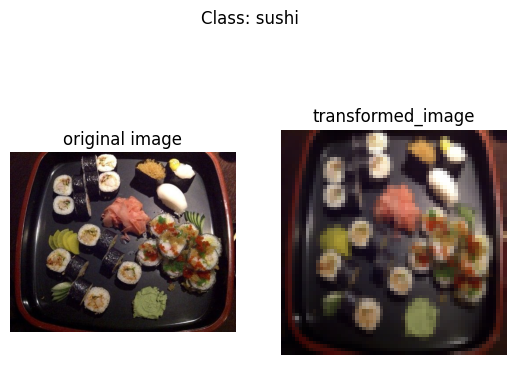

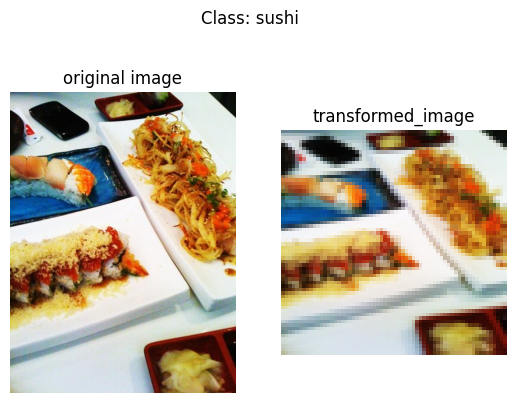

In [ ]:
def plot_transformed_images(image_paths, transform, n=3, seed= 42):
  random.seed(42)
  random_samples_path = random.sample(image_paths,k=n)
  for image_path in random_samples_path:
      fig , ax = plt.subplots(1,2)
      image_class = image_path.parent.stem
      image = Image.open(image_path)
      transformed_image = transform(image).permute(1,2,0)

      fig.suptitle(f"Class: {image_class}")

      ax[0].imshow(image)
      ax[0].set_title('original image')
      ax[0].axis(False)

      ax[1].imshow(transformed_image)
      ax[1].set_title('transformed_image')
      ax[1].axis(False)

plot_transformed_images(all_image_paths,transform_data)

In [ ]:
from torchvision import datasets

train_data = datasets.ImageFolder(root = train_dir,
                                  transform = transform_data,
                                  allow_empty=False,
                                  target_transform=None)

test_data = datasets.ImageFolder(root = test_dir,
                                  transform = transform_data,
                                  allow_empty=False)


In [ ]:
train_data[200][0], train_data[200][1]

(tensor([[[0.0118, 0.0118, 0.0118,  ..., 0.1294, 0.2039, 0.2196],
          [0.0078, 0.0118, 0.0118,  ..., 0.1725, 0.2000, 0.2196],
          [0.0078, 0.0078, 0.0078,  ..., 0.2392, 0.1843, 0.1843],
          ...,
          [0.8941, 0.9176, 0.9373,  ..., 0.8902, 0.8784, 0.8706],
          [0.8902, 0.9098, 0.9255,  ..., 0.8824, 0.8745, 0.8627],
          [0.8824, 0.8941, 0.9098,  ..., 0.8784, 0.8667, 0.8549]],
 
         [[0.0118, 0.0118, 0.0118,  ..., 0.1137, 0.1765, 0.1882],
          [0.0078, 0.0118, 0.0118,  ..., 0.1294, 0.1725, 0.1961],
          [0.0078, 0.0078, 0.0078,  ..., 0.1882, 0.1490, 0.1647],
          ...,
          [0.8627, 0.8824, 0.9059,  ..., 0.8431, 0.8314, 0.8235],
          [0.8510, 0.8667, 0.8863,  ..., 0.8431, 0.8314, 0.8235],
          [0.8510, 0.8588, 0.8706,  ..., 0.8392, 0.8275, 0.8157]],
 
         [[0.0196, 0.0196, 0.0196,  ..., 0.1176, 0.1765, 0.1882],
          [0.0157, 0.0196, 0.0196,  ..., 0.1255, 0.1725, 0.2000],
          [0.0157, 0.0157, 0.0157,  ...,

In [ ]:
train_data.classes

['pizza', 'steak', 'sushi']

In [ ]:
train_data.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
len(train_data) , len(test_data)

(225, 75)

In [ ]:
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [ ]:
test_data

Dataset ImageFolder
    Number of datapoints: 75
    Root location: data/pizza_steak_sushi/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [ ]:
train_data[0][0].device, train_data[0][0].type, train_data[0][0].dtype, train_data[0][0].ndim, train_data[0][0].shape

(device(type='cpu'),
 <function Tensor.type>,
 torch.float32,
 3,
 torch.Size([3, 64, 64]))

In [ ]:
print(f"label: {train_data[0][1]} || class: {train_data.classes[train_data[0][1]]}")

label: 0 || class: pizza


In [ ]:
os.cpu_count()

2

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset = train_data,
                              batch_size=32,
                              num_workers=2,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             num_workers=2,
                             batch_size=32,
                             shuffle=True)

In [ ]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b08fa3efaa0>,
 <torch.utils.data.dataloader.DataLoader at 0x7b08fa4087a0>)

In [ ]:
train_batch = next(iter(train_dataloader))
test_batch = next(iter(test_dataloader))

print(f"number of images in the train batch: {len(train_batch[0])}, shape of a single image: {train_batch[0].shape}")
print(f"number of images in the test batch: {len(test_batch[0])}, shape of a single image: {test_batch[0].shape}")

number of images in the train batch: 32, shape of a single image: torch.Size([32, 3, 64, 64])
number of images in the test batch: 32, shape of a single image: torch.Size([32, 3, 64, 64])


In [ ]:
from torch.utils.data import Dataset
import os
from pathlib import Path
from torchvision import transforms
from PIL import Image
from typing import Tuple, Dict, List


In [ ]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
target_directory = train_dir
print(f"target_directory: {target_directory}")

class_names = sorted([item.name for item in os.scandir(target_directory)])
print(f"class_names: {class_names}")

target_directory: data/pizza_steak_sushi/train
class_names: ['pizza', 'steak', 'sushi']


In [ ]:

def find_classes(directory: str)-> Tuple[List[str],Dict[str,int]]:

  class_names = sorted([item.name for item in os.scandir(directory)])

  if not class_names:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}.")
  class_to_idx = {name : idx for idx, name in enumerate(class_names)}

  return class_names,class_to_idx

In [ ]:
find_classes(train_dir)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
from pathlib import Path

class customImageFolder(Dataset):
  # definitely need to overwrite __getitem__, can __len__ also
  def __init__(self,target_directory:str ,transformations = None) -> None:

    self.paths = list(Path(target_directory).glob('*/*.jpg'))

    self.class_names, self.class_to_idx = find_classes(target_directory)

    self.transformations = transformations


  def load_image(self, index: int) -> Image.Image:
     image_path = self.paths[index]
     return Image.open(image_path)

  def __len__(self) ->int:
    return len(self.paths)

  def __getitem__(self, index) -> Tuple[torch.Tensor, int]:
      image = self.load_image(index)
      label = self.paths[index].parent.name
      class_idx = self.class_to_idx[label]
      if self.transformations:
            return self.transformations(image), class_idx
      else:
        return image, class_idx


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])


In [ ]:
train_dataset = customImageFolder(target_directory=train_dir,
                                  transformations=train_transforms)

test_dataset = customImageFolder(target_directory=test_dir,
                                  transformations=test_transforms)

train_dataset, test_dataset

(<__main__.customImageFolder at 0x7b08f9cec830>,
 <__main__.customImageFolder at 0x7b08f9cb5b50>)

In [ ]:
len(train_dataset), len(test_dataset)

(225, 75)

In [ ]:
def display_random_image(
    dataset: torch.utils.data.Dataset,
    n: int = 10,
    display_shape: bool = True,
    seed: int = None):

  if n>10:
    n=10
    print("Can't have n > 10, setting n to 10")
  if seed:
    random.seed(seed)

  random_samples_idx = random.sample(range(len(dataset)), k=n)
  fix, ax = plt.subplots(len(random_samples_idx),1)
  classes = dataset.class_names

  for i, random_idx in enumerate(random_samples_idx):
    image, class_label = dataset[random_idx][0], dataset[random_idx][1]
    image_adjusted = image.permute(1,2,0)

    ax[i].imshow(image_adjusted)
    ax[i].set_title(classes[class_label])
    ax[i].axis(False)




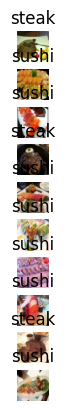

In [ ]:
display_random_image(train_dataset,seed=42)

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=32,
                              num_workers=os.cpu_count(),
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=32,
                              num_workers=os.cpu_count(),
                              shuffle=False)
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7b08f8cd7800>,
 <torch.utils.data.dataloader.DataLoader at 0x7b08fa0ba9c0>)

In [ ]:
class VGGMini(nn.Module):
  def __init__(self, input_channels:int, hidden_channels:int, output_shape: int):
    """Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/"""
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
        # 64 x 64 -> 32 x 32
    )
    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_channels,out_channels=hidden_channels,kernel_size=3,stride=1,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)
        # 32 x 32 -> 16 x 16
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        # colour channels x flattened image (16*16)
        nn.Linear(in_features=hidden_channels*16*16,out_features=output_shape)
    )

  def forward(self,x) -> torch.Tensor:
    # operator fusion
    return self.classifier(self.block_2(self.block_1(x)))

In [ ]:
torch.manual_seed(42)

model_0 = VGGMini(input_channels=3, # number of color channels (3 for RGB)
                  hidden_channels=10,
                  output_shape=len(train_data.classes)).to(device)

In [ ]:
model_0

VGGMini(
  (block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [ ]:
image_batch, label_batch = next(iter(train_dataloader))

pred_logits = model_0(image_batch[0].unsqueeze(dim=0))

pred_probs = torch.softmax(pred_logits, dim=1)
pred_label = torch.argmax(pred_probs,dim=1)
# every alternate time we run this the pred_label will most probably change
pred_label, label_batch[0]

(tensor([0]), tensor(1))

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

print(torchinfo.__version__)

1.8.0


In [ ]:
from torchinfo import summary

summary(model_0,[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
VGGMini                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

### Nice!

In [ ]:
def train_step(model:torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer) -> list[int,int]:

  model.train()
  model.to(device)
  train_loss = 0
  train_acc = 0

  for i, (X,y) in enumerate(dataloader):
    X.to(device), y.to(device)
    pred_logits = model(X)
    loss = loss_fn(pred_logits,y)
    train_loss += loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pred_label = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)
    train_acc += (pred_label == y).sum().item() / len(pred_logits)
    # this is accuracy on this batch

    print(f"Completed {i} batch out of {len(dataloader)} for training")

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)
  # average batch accuracy

  return train_loss, train_acc

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
def test_step(model:torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module) -> list[int,int]:

  model.eval()
  model.to(device)
  test_loss = 0
  test_acc = 0
  with torch.inference_mode():
    for i, (X,y) in enumerate(dataloader):
      X.to(device), y.to(device)
      pred_logits = model(X)
      loss = loss_fn(pred_logits,y)
      test_loss += loss.item()

      pred_label = torch.argmax(torch.softmax(pred_logits,dim=1),dim=1)
      test_acc += (pred_label == y).sum().item() / len(pred_logits)
      # this is accuracy on this batch

      print(f"Completed {i} batch out of {len(dataloader)} for testing")

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    # average batch accuracy

    return test_loss, test_acc

NameError: name 'torch' is not defined

In [ ]:
from tqdm.auto import tqdm

def train(model:torch.nn.Module,
               train_dataloader: torch.utils.data.DataLoader,
               test_dataloader: torch.utils.data.DataLoader,
               optimizer: torch.optim.Optimizer,
               loss_fn: torch.nn.Module = nn.CrossEntropyLoss,
               epochs: int = 5):

  results = {'train_loss':[],
             'train_acc':[],
             'test_loss':[],
             'test_acc':[],
             }
  for epoch in tqdm(range(epochs)):

      train_loss, train_acc = train_step(model = model,
                  dataloader = train_dataloader,
                  loss_fn = loss_fn,
                  optimizer = optimizer)

      test_loss, test_acc = test_step(model = model,
                  dataloader = test_dataloader,
                  loss_fn = loss_fn)

      print(
          f'Epoch: {epoch+1} |',
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
      )

      results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
      results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
      results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
      results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

  return results

In [ ]:
train_dataset.class_names

['pizza', 'steak', 'sushi']

In [ ]:
# rewriting some fluff for me to remember the structure

from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS = 5

train_dir = image_path / "train/"
test_dir = image_path / "test/"

training_transformations = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

testing_transformations = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

BATCH_SIZE = 32

train_dataset = customImageFolder(target_directory = train_dir,
                                  transformations=training_transformations)

test_dataset = customImageFolder(target_directory = test_dir,
                                     transformations= testing_transformations)

train_dataloader = DataLoader(dataset = train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle = True,
                              num_workers = os.cpu_count())

test_dataloader = DataLoader(dataset = test_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle = False,
                              num_workers = os.cpu_count())

class_names = train_dataset.class_names

model_1 = VGGMini(input_channels=3,
                  hidden_channels=10,
                  output_shape=len(class_names))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),lr = 0.01)

start_time = timer()

results = train(model = model_1,
      train_dataloader=train_dataloader,
      test_dataloader= test_dataloader,
      optimizer = optimizer,
      loss_fn = loss_fn,
      epochs = EPOCHS)

end_time = timer()

print(f"total training time: {end_time - start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Completed 0 batch out of 8 for training
Completed 1 batch out of 8 for training
Completed 2 batch out of 8 for training
Completed 3 batch out of 8 for training
Completed 4 batch out of 8 for training
Completed 5 batch out of 8 for training
Completed 6 batch out of 8 for training
Completed 7 batch out of 8 for training
Completed 0 batch out of 3 for testing
Completed 1 batch out of 3 for testing
Completed 2 batch out of 3 for testing
Epoch: 1 | train_loss: 1.1810 | train_acc: 0.2930 | test_loss: 1.1329 | test_acc: 0.2604
Completed 0 batch out of 8 for training
Completed 1 batch out of 8 for training
Completed 2 batch out of 8 for training
Completed 3 batch out of 8 for training
Completed 4 batch out of 8 for training
Completed 5 batch out of 8 for training
Completed 6 batch out of 8 for training
Completed 7 batch out of 8 for training
Completed 0 batch out of 3 for testing
Completed 1 batch out of 3 for testing
Completed 2 batch out of 3 for testing
Epoch: 2 | train_loss: 1.1137 | train

In [ ]:
def plot_loss_curves(results:dict) -> None:

    train_loss = results['train_loss']
    train_acc = results['train_acc']
    test_loss = results['test_loss']
    test_acc = results['test_acc']

    epochs = range(len(train_loss))

    plt.figure(figsize=(13,8))

    plt.subplot(1,2,1)
    plt.plot(epochs,train_loss,label='train_loss')
    plt.plot(epochs,test_loss,label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs,train_acc,label='train_acc')
    plt.plot(epochs,test_acc,label='test_acc')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()


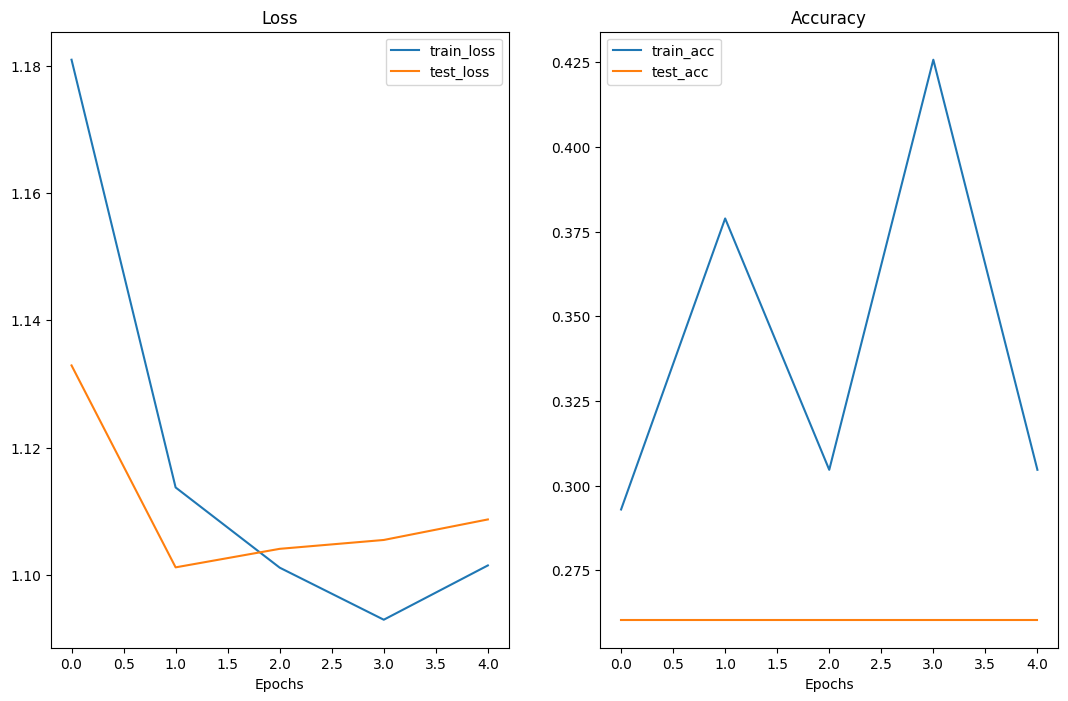

In [ ]:
plot_loss_curves(results)

In [ ]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);